In [1]:
import os
os.listdir('.')


['F5m_imag.npy',
 'F7_real.npy',
 'c.npy',
 'F5m_real.npy',
 '.kernel_llm_logs_1.txt',
 'rho0.npy',
 'description.npy',
 'F5p_t.npy',
 'F5p_imag.npy',
 'a.npy',
 'lambda_n.npy',
 'F2_imag.npy',
 'F5m_t.npy',
 'F6_real.npy',
 'F2_real.npy',
 ' v6 — Binding Context Document.pdf',
 'F7_imag.npy',
 'memory',
 'N.npy',
 'F6_imag.npy',
 'F1_t.npy',
 'F6_t.npy',
 'a_n.npy',
 'F4_real.npy',
 '.config',
 'F4_t.npy',
 'F7_t.npy',
 'F1_real.npy',
 'F5p_real.npy',
 'F2_t.npy',
 'peaks_features_F1_F12_normalized_full.csv',
 '.prompts',
 'F4_imag.npy',
 'F1_imag.npy']

In [2]:
import numpy as np
# Inspect the available complex Sk arrays
for name in ['F1_real.npy','F1_imag.npy','F1_t.npy']:
 arr = np.load(name, allow_pickle=True)
 print(name, arr.shape, arr.dtype)


F1_real.npy (200, 8) float64
F1_imag.npy (200, 8) float64
F1_t.npy (200,) float64


In [3]:
import pandas as pd
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df['class'].value_counts() if 'class' in df.columns else df.head())


(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6

In [4]:
df['function'].value_counts()


function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64

In [5]:
# Check what classes have complex S_k available locally as .npy
import os
classes_avail = []
for f in os.listdir('.'):
 if f.endswith('_real.npy'):
 classes_avail.append(f.replace('_real.npy',''))
print(sorted(classes_avail))


['F1', 'F2', 'F4', 'F5m', 'F5p', 'F6', 'F7']


In [6]:
# We need complex S_k for F9, F10, F11, F12 also. Let's check the description from primary dataset.
# The Sk_complex_arrays.npz only has 7 classes. We need to generate complex S_k for F9, F10, F11, F12 from coefficients.

# Check for the npz artifact
for f in os.listdir('.'):
 if 'Sk_complex' in f or 'coeffs' in f:
 print(f)


In [7]:
# Check what a.npy, a_n.npy, lambda_n.npy contain
for f in ['a.npy','a_n.npy','c.npy','lambda_n.npy','N.npy','rho0.npy','description.npy']:
 arr = np.load(f, allow_pickle=True)
 print(f, arr.shape if hasattr(arr,'shape') else type(arr), arr.dtype if hasattr(arr,'dtype') else '', 
 str(arr)[:120] if arr.size<5 else '')


a.npy (1000000,) complex128 


a_n.npy (1000000,) object 
c.npy () complex128 (-0.16567330026345564+1.9009252335917202j)
lambda_n.npy (1000000,) float64 
N.npy () int64 1000000
rho0.npy () complex128 (0.7+7j)
description.npy () <U334 F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3


In [8]:
# a.npy is F12 coefficients (complex), a_n.npy is likely F9 (Ramanujan tau) - object/integer
# lambda_n.npy is float64 normalized (length 1e6) - probably F9 normalized
print('a_n[0:10]:', np.load('a_n.npy', allow_pickle=True)[:10])
print('lambda_n[0:10]:', np.load('lambda_n.npy', allow_pickle=True)[:10])
print('a[0:10]:', np.load('a.npy', allow_pickle=True)[:10])


a_n[0:10]: [1 -1472 -113643 5181440 -25499225 167282496 -1696965207 -3474718720
 33046247970 37534859200]
lambda_n[0:10]: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413 0.46109111
 -0.85821183 -0.4045105 1.05306348 0.37534859]
a[0:10]: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j -0.1656733+1.90092523j
 1.1656733-1.90092523j -0.8343267-1.90092523j -0.1656733+1.90092523j
 1. +0.j ]


In [9]:
# Good. a_n is F9 (tau values). lambda_n is normalized lambda for F9. Sum_n a_n / n^11/2 normalization etc.
# We need to derive complex Sk for F9, F10, F11, F12 too. But that's expensive.
# 
# Actually, look more carefully: the research objective says to reconstruct complex S_k for ALL 2200 peaks (11 classes x 200).
# But complex data only available for 7 classes (F1,F2,F4,F5p,F5m,F6,F7).
# 
# However, the strict protocol is Train: F1, F4, F9; Test: F2, F6, F7, F10, F11, F12.
# We need F9, F10, F11, F12 complex S_k.
# 
# Generating S_k requires the peak t-values + coefficients + ω-stratification.
# Let me think: do we have peak t values for F9-F12?

for cls in ['F9','F10','F11','F12']:
 sub = df[df['function']==cls]
 print(cls, sub['t'].head().tolist(), 'count:', len(sub))


F9 [96853.90000031596, 93405.40000030345, 46051.60000013116, 82510.0000002638, 64946.00000019989] count: 200
F10 [90977.1000002946, 72031.90000022567, 61534.80000018748, 71308.90000022305, 89456.10000028907] count: 200
F11 [43714.800000122654, 31241.60000007728, 25658.800000056966, 18116.100000029524, 96372.10000031424] count: 200
F12 [93969.30000030548, 94993.4000003092, 48038.50000013838, 75839.60000023953, 97967.30000032004] count: 200


In [10]:
# We don't have F9-F12 coefficient files (.npz). The artifact descriptions say these exist but they're absent. 
# We have F12 coefficients available as a.npy and F9 (a_n.npy / lambda_n.npy).
# We don't have F10, F11 coefficients.
#
# Generating coefficients requires PARI/GP via cypari2, which may need install.
# 
# Strategy: Given the complexity, we'll work with what we have - generate complex Sk for F9 from a_n,
# F12 from a.npy. F10, F11 require generating coefficients which is expensive and may be infeasible.
#
# Let me reconsider scope: the research question is whether instantaneous spectral features have classification power.
# The strict protocol trains on F1,F4,F9 and tests on F2,F6,F7,F10,F11,F12.
# We need at minimum: F1, F4, F9 (train) and F2, F6, F7, F10, F11, F12 (test) = 9 classes.
#
# We can do F1, F2, F4, F6, F7 (have complex), F9 (have coeffs), F12 (have coeffs).
# F10, F11 require generating coefficients via cypari2.
#
# Let me check if cypari2 is available
try:
 import cypari2
 print('cypari2 available')
except ImportError as e:
 print('cypari2 NOT available:', e)


cypari2 NOT available: No module named 'cypari2'


In [11]:
# Try install
import subprocess
r = subprocess.run(['pip','install','cypari2','-q'], capture_output=True, text=True, timeout=300)
print('stdout:', r.stdout[-500:])
print('stderr:', r.stderr[-500:])


stdout: 
stderr: 


In [12]:
try:
 import cypari2
 print('cypari2 OK')
except ImportError as e:
 print('still missing:', e)


cypari2 OK


In [13]:
# cypari2 available. Now let's plan computationally.
#
# To compute S_k(t) at a peak we need to know the formula. From the dataset description:
# S_k = ω-stratified sums where ω(n) is the number of distinct prime factors of n.
# More specifically, the "main sum" approximates an L-function on the critical line.
#
# Standard formulation: M(t) = sum_{n<=N} a_n / n^(1/2 + i*t)
# Stratified by ω(n) into S_k for k = 0..7 (number of distinct primes).
# k=0: only n=1, k=1: prime powers, etc.
#
# So S_k(t) = sum_{n<=N, omega(n)=k} a_n / n^(1/2 + i*t)
#
# Note: For F9 (Ramanujan Δ), the normalized coeffs lambda_n = a_n / n^(11/2) ensure functional eq centered at 1/2.
# For F12, a_n is already given complex.
#
# I need the ω(n) array up to N=10^6. Let me check what we can do.
# 
# Actually, for the 7 classes we have, the complex S_k is already done. We need to generate S_k for F9, F10, F11, F12.
# This is a substantial computation: 200 peaks x 4 classes x 8 strata = 6400 "stratified main sum" evaluations,
# each over up to 10^6 terms. That's ~6.4e9 operations. Feasible if vectorized.
#
# Let me first compute omega(n) for n=1..N once.
N = 1_000_000
import numpy as np
import time
t0 = time.time()
# Smallest prime factor sieve
spf = np.zeros(N+1, dtype=np.int32)
for i in range(2, N+1):
 if spf[i]==0:
 for j in range(i, N+1, i):
 if spf[j]==0:
 spf[j] = i
print('spf done', time.time()-t0)


spf done 0.5838956832885742


In [14]:
from numba import njit

@njit(cache=True)
def compute_omega(spf, N):
 omega = np.zeros(N+1, dtype=np.int8)
 for n in range(2, N+1):
 x = n
 count = 0
 last_p = 0
 while x > 1:
 p = spf[x]
 if p != last_p:
 count += 1
 last_p = p
 x //= p
 omega[n] = count
 return omega

t0 = time.time()
omega = compute_omega(spf, N)
print('omega done', time.time()-t0)
print('omega max:', omega.max(), 'distrib:', np.bincount(omega.astype(np.int64))[:10])


omega done 1.2089312076568604
omega max: 7 distrib: [ 2 78734 288726 379720 208034 42492 2285 8]


In [15]:
# Good. omega in [0..7]. Note: omega[1]=0, omega[0]=0 (we'll skip).
# Note distrib shows omega[1]=0 contributes 1 element (n=1), but bincount[0]=2 (n=0 also). OK.
#
# Now, for each class, we need a_n (coefficients) and the "main sum" to evaluate.
#
# Standard approximation: For an L-function L(s) with coefficients a_n,
# the partial main sum at s = 1/2 + i*t is M(t) = sum_{n<=N} a_n/sqrt(n) * exp(-i*t*log(n))
# After dividing by some normalization. But the dataset says abs_S0=1 and log_abs_S0=0 for all rows,
# meaning S_0 is identically 1 (the n=1 contribution always equals a_1/1^s = 1).
#
# Let's check dataset: 
print(df.groupby('function')[['abs_S0','log_abs_S0']].describe().head(20))


 abs_S0 \
 count mean std min 25% 50% 75% 
function 
F1 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F10 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F11 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F12 200.0 2.075962 0.0 2.075962 2.075962 2.075962 2.075962 
F2 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F4 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F5m 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F5p 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F6 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F7 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 
F9 200.0 1.000000 0.0 1.000000 1.000000 1.000000 1.000000 

 log_abs_S0 \
 max count mean std min 25% 50% 
function 
F1 1.000000 200.0 0.000000 0.0 0.000000 0.000000 0.000000 
F10 1.000000 200.0 0.000000 0.0 0.000000 0.000000 0.000000 
F11 1.000000 200.0 0.000000 0.0 0.000000 0.000000 0.000000 
F12 2.075962 200.0 0.730425 0.0 0.730425 0.730425 0.7304

In [16]:
# For F12, S_0 = a_1 = c+chi3(1)+c*chi5(1) - actually a[0] = a_1 = chi3(1)+c*chi5(1) = 1 + c
# |1+c| = |1 + (-0.166+1.901i)| = |0.834+1.901i| = sqrt(0.696+3.614) = sqrt(4.31) = 2.076. Matches!
#
# Verify: For F1 (zeta), the existing complex S_k from F1_real/F1_imag should match abs_S0=1, abs_S1, etc.
F1_real = np.load('F1_real.npy')
F1_imag = np.load('F1_imag.npy')
F1_t = np.load('F1_t.npy')
F1_c = F1_real + 1j*F1_imag
print('F1_c shape:', F1_c.shape)
print('F1 abs S0[0]:', np.abs(F1_c[0,0]))
print('F1 abs S1[0]:', np.abs(F1_c[0,1]))
print('df F1 abs_S0[0]:', df[df.function=='F1']['abs_S0'].iloc[0], 'abs_S1[0]:', df[df.function=='F1']['abs_S1'].iloc[0])
print('F1_t[0]:', F1_t[0], 'df t[0]:', df[df.function=='F1']['t'].iloc[0])


F1_c shape: (200, 8)
F1 abs S0[0]: 1.0
F1 abs S1[0]: 4.4323107043908205
df F1 abs_S0[0]: 1.0 abs_S1[0]: 5.315306810626032
F1_t[0]: 22299.04000001989 df t[0]: 77403.70000024521


In [17]:
# The peak ordering doesn't match between the .npy files and the CSV.
# Let me check: for each class, do t-values in npy match those in df?
for cls in ['F1','F2','F4','F5p','F5m','F6','F7']:
 t_npy = np.load(f'{cls}_t.npy')
 t_df = df[df.function==cls]['t'].values
 # check sets
 s_npy = set(np.round(t_npy,3))
 s_df = set(np.round(t_df,3))
 print(cls, 'overlap:', len(s_npy & s_df), 'npy only:', len(s_npy-s_df), 'df only:', len(s_df-s_npy))


F1 overlap: 18 npy only: 182 df only: 182
F2 overlap: 18 npy only: 182 df only: 182
F4 overlap: 8 npy only: 192 df only: 192
F5p overlap: 8 npy only: 192 df only: 192
F5m overlap: 8 npy only: 192 df only: 192
F6 overlap: 25 npy only: 175 df only: 175
F7 overlap: 24 npy only: 176 df only: 176


In [18]:
# Mismatch. The existing complex .npy peaks don't match the CSV peaks. 
# This means the npy artifacts were generated for a different peak selection.
# 
# Given research objective requires complex S_k for ALL 2200 peaks of the CSV, we will need to regenerate 
# the complex S_k for each CSV t-value by computing the partial main sum directly.
#
# Let's check whether the CSV's reported abs_S_k actually agree with abs(F*_real+i*F*_imag) for the matching t-values.
# Take F1 overlapping points:
t_npy = np.load('F1_t.npy')
t_df = df[df.function=='F1']['t'].values
# Find an exact match
for i,t in enumerate(t_npy):
 matches = np.where(np.isclose(t_df, t, atol=1e-2))[0]
 if len(matches):
 j = matches[0]
 print('npy idx',i,'t=',t,' df idx',j,'t=',t_df[j])
 print('npy |S_k|:', np.abs(F1_c[i]))
 print('df |S_k|:', df[df.function=='F1'].iloc[j][['abs_S0','abs_S1','abs_S2','abs_S3','abs_S4','abs_S5','abs_S6','abs_S7']].values)
 break


npy idx 0 t= 22299.04000001989 df idx 125 t= 22299.100000044746
npy |S_k|: [1.00000000e+00 4.43231070e+00 7.92566878e+00 5.76196911e+00
 1.63851847e+00 4.18062428e-01 1.32470388e-01 4.64495018e-03]
df |S_k|: [np.float64(1.0) np.float64(4.480454856990655)
 np.float64(7.929151746690291) np.float64(5.670532315615527)
 np.float64(1.827933501387361) np.float64(0.370519318518454)
 np.float64(0.1261657367130844) np.float64(0.0046629084322875)]


In [19]:
# Nearly matches but not exactly - because t differs by 0.06. The two peak sets are slightly different t values.
# So the complex npy is likely from a different peak-detection run, with similar but distinct peaks.
#
# Approach: We'll regenerate complex S_k for the CSV's t-values. This requires:
# - For each class, get coefficients a_n
# - For each peak t in the CSV, compute S_k(t) = sum_{n: omega(n)=k} a_n * n^(-1/2) * exp(-i*t*log n)
# - For modular forms, use normalized lambda_n.
#
# Coefficient sources:
# F1 (zeta): a_n = 1
# F2: Dirichlet character mod 5? Actually F2 in : need to identify. The dataset description mentions
# "mod-5 coefficients (F2, F4, F5±)". Let me look at the document.
#
# This is getting deep. Given we have the CSV with magnitudes already, and complex npy for 7 classes,
# but not aligned, a cleaner approach: use the npy file's t-values and corresponding magnitudes (regenerate features
# from npy directly), and need to also compute for F9, F10, F11, F12.
#
# Let me reconsider: Do the .npy t-arrays correspond to a different set of 200 peaks per class? And
# are those peaks already complete sets (so we have full instantaneous data for them)?
# Yes: 200 peaks each.

# Let me check F4 and the others - do they have 200?
for cls in ['F1','F2','F4','F5p','F5m','F6','F7']:
 t_arr = np.load(f'{cls}_t.npy')
 r_arr = np.load(f'{cls}_real.npy')
 i_arr = np.load(f'{cls}_imag.npy')
 print(cls, t_arr.shape, r_arr.shape, i_arr.shape)


F1 (200,) (200, 8) (200, 8)
F2 (200,) (200, 8) (200, 8)
F4 (200,) (200, 8) (200, 8)
F5p (200,) (200, 8) (200, 8)
F5m (200,) (200, 8) (200, 8)
F6 (200,) (200, 8) (200, 8)
F7 (200,) (200, 8) (200, 8)


In [20]:
# Good. Each npy has 200 peaks worth of complex S_k for 7 classes.
# 
# Strategy refinement:
# - Use the existing 7 classes' complex Sk arrays directly (200 peaks each, total 1400 peaks).
# - Generate complex S_k for F9, F10, F11, F12 (200 peaks each from the CSV t-values).
# - This requires coefficient generation for F10, F11 via cypari2 + ω-stratified main sum computation.
# 
# But peak t values must match the CSV t-values for F9, F10, F11, F12 (since CSV has features but no complex).
# 
# Actually, since the npy and CSV t-values differ for the 7 known classes, we have two choices:
# A) For classes with .npy files, use the .npy t-values; for F9-F12, use CSV t-values. Mix sources but carefully.
# B) Regenerate complex S_k for ALL classes at the CSV t-values. Most rigorous, requires F1-F7 coefficient regen too.
#
# Given runtime constraints (3600s), and we already have F1-F7 complex done, we'll do (A): 
# use the 1400 .npy peaks for F1,F2,F4,F5p,F5m,F6,F7, and generate 800 new peaks for F9,F10,F11,F12.
# 
# But for the **strict protocol** (Train: F1,F4,F9; Test: F2,F6,F7,F10,F11,F12), we need:
# - F1, F4, F2, F6, F7 from .npy (have it)
# - F9, F10, F11, F12 newly computed
# Note F5p, F5m don't enter strict protocol but we can include them as auxiliaries.
#
# Let me start by computing F9 (we have a_n for tau). First validate normalization:
# The Ramanujan Δ has functional equation centered at s=1/2 after normalization a_n / n^{(k-1)/2}, k=12.
# For k=12, the normalization is n^{(12-1)/2} = n^{11/2}. lambda_n = a_n / n^{11/2}.
# Then L(s,Δ) (analytic) = sum lambda_n / n^s. So for the partial main sum: M(t) = sum_{n<=N} lambda_n / n^{1/2 + i*t}
# i.e., S_0 (n=1) = lambda_1 = 1. Good.

# For F12: a_n is given complex (from a.npy). S_0 = a_1 = 1+c. |1+c| = 2.076 (matches CSV).
# So for F12 we should NOT do |a_1| normalization; the CSV uses S_k as-is from raw a_n.

# Verify how S_k normalization is done relative to CSV. For F1, S_0 = 1 means a_1 = 1 (zeta).
# For F9, S_0 = 1 means lambda_1 = 1 = a_1/1^{11/2} = 1. Correct.

# So the rule: for modular forms (F9, F10, F11), use lambda_n = a_n / n^{(k-1)/2} as the coefficients.
# For F12, use raw a_n.

# Let me build a generic function to compute S_k for a given class.

# First compute precomputed arrays
n_arr = np.arange(1, N+1, dtype=np.int64)
sqrt_n = np.sqrt(n_arr.astype(np.float64))
log_n = np.log(n_arr.astype(np.float64))
omega_full = omega[1:N+1] # length N
print('Arrays prepared. N =', N)
print('omega[1:11]:', omega_full[:10])


Arrays prepared. N = 1000000
omega[1:11]: [0 1 1 1 1 2 1 1 1 2]


In [21]:
# Quick sanity: for n=10, omega should be 2 (factors 2,5). Yes. n=1 -> 0. 
# 
# Now, the partial sum requires careful summation. With complex arithmetic over 1e6 terms x 200 peaks x 4 classes
# = 8e8 operations per class. Total 3.2e9 ops. With numpy vectorization (no Python loop over n),
# we can do ~5e8 ops/sec, so each peak is ~1e6 ops -> 1ms ideal but complex math is slower.
# 
# Better: use numba to write a direct loop computing all 8 S_k buckets at once.

@njit(cache=True, fastmath=True, parallel=False)
def compute_Sk_for_one_t(coef_real, coef_imag, sqrt_n, log_n, omega_full, t):
 # Returns 8 complex S_k values
 Sr = np.zeros(8)
 Si = np.zeros(8)
 Nn = coef_real.shape[0]
 for n in range(Nn):
 ang = -t * log_n[n]
 c = np.cos(ang)
 s = np.sin(ang)
 # term = (cr + i ci) * (c + i s) / sqrt(n+1)
 cr = coef_real[n]
 ci = coef_imag[n]
 inv = 1.0 / sqrt_n[n]
 tr = (cr*c - ci*s) * inv
 ti = (cr*s + ci*c) * inv
 k = omega_full[n]
 Sr[k] += tr
 Si[k] += ti
 return Sr, Si

# Compile + test on F1 (zeta)
import time
coef_real = np.ones(N, dtype=np.float64)
coef_imag = np.zeros(N, dtype=np.float64)
t_test = 22299.04
t0=time.time()
Sr, Si = compute_Sk_for_one_t(coef_real, coef_imag, sqrt_n, log_n, omega_full, t_test)
print('compile+1 peak', time.time()-t0, 'abs S_k:', np.sqrt(Sr**2+Si**2))
t0=time.time()
Sr, Si = compute_Sk_for_one_t(coef_real, coef_imag, sqrt_n, log_n, omega_full, t_test)
print('1 peak', time.time()-t0)
print('Expected from npy F1[0]:', np.abs(F1_c[0]))


compile+1 peak 0.3335855007171631 abs S_k: [1.00000000e+00 4.43231070e+00 7.92566875e+00 5.76196912e+00
 1.63851842e+00 4.18062448e-01 1.32470390e-01 4.64495018e-03]
1 peak 0.02150702476501465
Expected from npy F1[0]: [1.00000000e+00 4.43231070e+00 7.92566878e+00 5.76196911e+00
 1.63851847e+00 4.18062428e-01 1.32470388e-01 4.64495018e-03]


In [22]:
# Excellent! Matches existing npy data to 8 decimal places. 21ms per peak.
# 200 peaks per class x 4 classes = 800 peaks = ~17 seconds. Very feasible.
# Plus regenerating F1, F2, F4, F5p, F5m, F6, F7 at the CSV t-values would also take ~140 seconds for 1400 peaks.
# Let's regenerate ALL 2200 from coefficients to use the CSV t-values consistently.
#
# Coefficients we need:
# F1: a_n = 1 (zeta) — easy
# F2: ? — from PDF
# F4: ? — GRH violator
# F5p, F5m: ? 
# F6, F7: ?
# F9: lambda_n already in lambda_n.npy
# F10: level-11 wt-2 newform — need cypari2
# F11: Sym²Δ from F9: b_p = tau(p)^2 - p^11
# F12: a.npy
#
# Let me check the PDF for F1-F7 definitions.


In [23]:
# So:
# F1: zeta -> a_n=1
# F2: L(s,χ_4), χ_4 mod 5 -> primitive Dirichlet character mod 5 of order 4
# F4: L_DH (Davenport-Heilbronn) with κ ≈ 0.28408
# F5: L_DH(ε), ε∈{±0.05} (F5p, F5m)
# F6: Liouville λ(n) = (-1)^Ω(n)
# F7: Möbius μ(n)
# F9: Δ (Ramanujan, weight 12)
# F10: level 11/17/23, weight 2/4 newform
# F11: Sym²L(s,Δ)
# F12: chi3+chi5 combo (have)
#
# This is substantial but manageable. Let me note: the existing complex .npy files give us F1, F2, F4, F5p, F5m, F6, F7
# already validated. To match CSV t-values, regenerate. But that means we need a_n for each.
#
# Actually, let's take a pragmatic approach: 
# - Keep existing complex npy data (validated). Use their 200 peaks for F1, F2, F4, F5p, F5m, F6, F7.
# - Generate new complex Sk for F9, F10, F11, F12 at... what t-values?
#
# Actually the cleanest: ditch the CSV t-values. Use whatever 200 peaks we have complex Sk for in npy 
# (for 7 classes), and for F9-F12 generate complex Sk for the CSV's 200 peaks. That's the new feature table.
#
# But the magnitudes from CSV won't match for the 7 npy classes (different t-values).
# Solution: For the 7 classes with .npy, recompute log|S_k| from the npy (consistent). For F9-F12, use CSV magnitudes 
# computed at the same t-values where we'll compute complex.
#
# Even simpler/better: Regenerate the entire feature table from coefficients for all 11 classes at consistent peak sets.
# For the 7 .npy classes, use the existing peaks. For F9-F12, use the CSV peaks.
#
# Then we need coefficients for F9, F10, F11, F12 to compute their complex Sk at the CSV peaks.
# 
# Let's prioritize - since only F9 (a_n.npy) and F12 (a.npy) coefficients are immediately available,
# we'll generate F10 and F11 coefficients using cypari2.

import cypari2
pari = cypari2.Pari()
pari.allocatemem(4*1024*1024*1024) # 4 GB
print('PARI version:', pari.version())


PARI stack size set to 4294967296 bytes, maximum size set to 4294967296
PARI version: (2, 17, 2)


In [24]:
# Generate F10 = level-11 weight-2 newform 11.2.a.a
# Then we'll do F11 from F9 (Sym²Δ).
import time
t0 = time.time()
# Level 11 weight 2 newforms space
mf = pari('mfinit([11,2],0)') # cuspidal newforms
forms = pari('mfbasis(mfinit([11,2],0))')
print('basis size:', len(forms))
# Use eigenforms
ef = pari('mfeigenbasis(mfinit([11,2],0))')
print('num eigenforms:', len(ef))
print('time:', time.time()-t0)


basis size: 1
num eigenforms: 1
time: 0.032846689224243164


In [25]:
# Generate first 1e6 coefficients for F10
t0 = time.time()
# We use mfcoefs which returns a vector of coefficients [a_0, a_1, ..., a_N]
# For wt 2 newform 11.2.a.a, a_n are integers.
# Be careful: this might be memory intensive
mf11 = pari('mfinit([11,2],0)')
ef11 = pari('mfeigenbasis(mfinit([11,2],0))[1]')
print('Computing F10 coefficients...')
coefs_F10 = pari.mfcoefs(ef11, N) # gives [a_0, a_1, ..., a_N], length N+1
print('time:', time.time()-t0)
print('len:', len(coefs_F10))
print('first 10:', [int(coefs_F10[i]) for i in range(11)])


Computing F10 coefficients...
time: 192.9683699607849
len: 1000001
first 10: [0, 1, -2, -1, 2, 1, 2, -2, 0, -2, -2]


In [26]:
# Convert to numpy (int64). First entry is a_0 (=0). a_1=1, a_2=-2 etc.
# These are the eigenvalues, so for weight 2, lambda_n = a_n / sqrt(n).
t0=time.time()
F10_a = np.zeros(N+1, dtype=np.int64)
for i in range(N+1):
 F10_a[i] = int(coefs_F10[i])
print('convert time:', time.time()-t0)
print('a[1:11]:', F10_a[1:11])
F10_lambda = F10_a[1:].astype(np.float64) / np.sqrt(np.arange(1, N+1, dtype=np.float64))
print('lambda[0:5]:', F10_lambda[:5])
np.save('coeffs_F10_lambda.npy', F10_lambda)
print('saved')


convert time: 1.4888458251953125
a[1:11]: [ 1 -2 -1 2 1 2 -2 0 -2 -2]
lambda[0:5]: [ 1. -1.41421356 -0.57735027 1. 0.4472136 ]
saved


In [27]:
# Now F11 = Sym²(Δ). Recurrence at primes: b_p = tau(p)^2 - p^11. Multiplicative.
# At prime powers: b_{p^r} obeys the relation from Sym^2: 
# If alpha + beta = tau(p), alpha*beta = p^11, then 
# Sym^2 has roots alpha^2, alpha*beta = p^11, beta^2.
# So local factor = (1 - alpha^2 p^-s)(1 - p^11 p^-s)(1 - beta^2 p^-s).
# 
# Let me use a recurrence for b_{p^r}. With three roots gamma_i = {alpha^2, p^11, beta^2}:
# e1 = alpha^2 + p^11 + beta^2 = tau(p)^2 - p^11
# e2 = alpha^2 * p^11 + alpha^2 * beta^2 + p^11 * beta^2 = p^11*(alpha^2+beta^2) + (alpha*beta)^2 
# = p^11*(tau(p)^2 - 2 p^11) + p^22 = p^11 tau(p)^2 - p^22
# e3 = alpha^2 * p^11 * beta^2 = p^11 * (alpha*beta)^2 = p^11 * p^22 = p^33
# Recurrence: b_{p^r} = e1 b_{p^{r-1}} - e2 b_{p^{r-2}} + e3 b_{p^{r-3}}
# with b_1=1.
#
# We have tau(p) = a_n.npy[p-1] for prime p.
# 
# This requires computing F11 coefficients at all n<=N via multiplicativity using prime power values.

tau = np.load('a_n.npy', allow_pickle=True) # length N, a_n for n=1..N (Python ints in object array)
print('tau[0]:', tau[0], 'tau[1]:', tau[1]) # tau(1)=1, tau(2)=-24


tau[0]: 1 tau[1]: -1472


In [28]:
# Wait, tau(2)=-24 but tau[1]=-1472. Let me check. tau[0]=a_1=1 yes. tau[1]=a_2=-1472.
# But Ramanujan tau(2) = -24, not -1472. Hmm. 
# Actually a_n.npy might be tau_n with normalized weight differently? -1472 = -24 * 61.33? no.
# 
# Recall lambda_n.npy: lambda_n[1] = -0.71875. If a_n[1] = -1472 and lambda_n = a_n/n^{(k-1)/2}, k=12 -> n^{11/2}.
# 2^{11/2} = sqrt(2^11) = sqrt(2048) = 45.25. -1472/45.25 = -32.5. Not -0.71875.
# 
# Or lambda_n = a_n/n^k? For k=12: 2^12 = 4096. -1472/4096 = -0.359. Not matching either.
# 
# Try lambda_n = a_n/n^{6}: 2^6 = 64. -1472/64 = -23. close to -24? hmm.
# 
# Let me check the description embedded in description.npy
desc = np.load('description.npy', allow_pickle=True)
print(str(desc))


F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50.


In [29]:
# OK so description.npy is for F12 only. The a_n.npy and lambda_n.npy must be from Ramanujan Δ-related computation.
# Wait: tau(2)=-24, but a_n[1]=-1472. 
# 
# Let me try: -1472 = -24 - 1448 = ... or -1472 corresponds to a different normalization.
# Actually weight 12 Eisenstein-related? Let me check k=12 newform value via PARI.

t0=time.time()
mfDelta = pari('mfinit([1,12],0)')
ef_delta = pari('mfeigenbasis(mfinit([1,12],0))')
print('Delta eigenforms:', len(ef_delta))
delta_coefs = pari.mfcoefs(ef_delta[0], 20)
print('delta coefs[0:11]:', [int(delta_coefs[i]) for i in range(11)])


Delta eigenforms: 1
delta coefs[0:11]: [0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]


In [30]:
# So Ramanujan tau is: 1, -24, 252, -1472, 4830, -6048, ...
# But a_n.npy has: 1, -1472, -113643, 5181440, -25499225, 167282496, -1696965207, ...
# These are NOT tau values. Let's check: is this Sym²Δ or Sym³Δ?
# 
# Sym²(Δ) at primes: b_p = tau(p)^2 - p^11.
# At p=2: tau(2)=-24, b_2 = 576 - 2048 = -1472. ✅
# At p=3: tau(3)=252, b_3 = 252^2 - 3^11 = 63504 - 177147 = -113643. ✅
# At p=5: tau(5)=4830, b_5 = 4830^2 - 5^11 = 23328900 - 48828125 = -25499225. ✅
#
# So a_n.npy is actually F11 (Sym²Δ), NOT F9!
# And lambda_n.npy is normalized... lambda[1]=-0.71875 = -1472/2048 = -1472/2^11.
# So lambda_n = b_n/n^11 (since for Sym² centered at s=1/2, weight-related factor is n^11 -> sqrt(n^22)=n^11).
# 
# Wait: F11 is Sym²(Δ) which has weight (2k-1)=23, so degree 3 L-function. Center 1/2.
# Normalized lambda = b_n / n^11. lambda[1] = -1472/2048 = -0.71875. ✅
#
# So we mislabeled. a_n.npy is actually F11 coefficients, not F9.
# We do NOT have F9 (Δ) coefficients pre-computed locally. Need to generate.
#
# We have:
# F10 ✓ just generated
# F11: we have b_n in a_n.npy + lambda_n.npy
# F9: need to generate (use Delta from PARI)
# F12: have

# Generate F9 (Delta) coefficients
t0=time.time()
print('Computing F9 (Delta) coefficients up to N=1e6...')
delta_coefs_full = pari.mfcoefs(ef_delta[0], N)
print('time:', time.time()-t0)
print('first 11:', [int(delta_coefs_full[i]) for i in range(11)])


Computing F9 (Delta) coefficients up to N=1e6...
time: 247.8693208694458
first 11: [0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]


In [31]:
# Convert to numpy array
t0 = time.time()
F9_a = np.zeros(N+1, dtype=object)
for i in range(N+1):
 F9_a[i] = int(delta_coefs_full[i])
print('convert time:', time.time()-t0)
# Now lambda_n = a_n / n^{11/2} (k=12 weight, normalize for analytic L-function with center 1/2)
# Compute as float
F9_lambda = np.zeros(N, dtype=np.float64)
for i in range(1, N+1):
 F9_lambda[i-1] = float(F9_a[i]) / (i**(5.5))
print('F9 lambda[0:5]:', F9_lambda[:5])
np.save('coeffs_F9_lambda.npy', F9_lambda)
print('saved')


convert time: 1.3099045753479004


F9 lambda[0:5]: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333]
saved


In [32]:
# Now F11. The artifact says lambda_n=b_n/n^11. 
# But for L-function of degree 3 with motivic weight w=22 (Sym^2 of weight-12 = motivic weight 22),
# the analytic normalization centered at 1/2 uses lambda_n = b_n / n^{11}.
# Actually for symmetric powers of weight-k newform: motivic weight = (k-1)*2 = 22, 
# so normalization is n^{11}. ✓
F11_lambda = np.array([float(x) for x in lambda_n_arr := np.load('lambda_n.npy', allow_pickle=False)])
print('F11 lambda[0:5]:', F11_lambda[:5])
print('len:', len(F11_lambda))


SyntaxError: invalid syntax (1626171070.py, line 6)

In [33]:
F11_lambda = np.load('lambda_n.npy', allow_pickle=False)
print('F11 lambda[0:5]:', F11_lambda[:5])
print('len:', len(F11_lambda))
print('F12 a[0:3]:', np.load('a.npy', allow_pickle=False)[:3])


F11 lambda[0:5]: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413]
len: 1000000
F12 a[0:3]: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j]


In [34]:
# Verify: For F12, a_1 = 1+c. c = -0.166+1.901j. a[0] should be 1+c = 0.834+1.901j. Yes.
# 
# But wait, the description says a_n = chi3(n)+c*chi5(n). At n=1: chi3(1)+c*chi5(1) = 1+c*1 = 1+c = 0.834+1.901j. ✓
# 
# Now we have all 4 sets of coefficients. Let's compute complex S_k for F9, F10, F11, F12 at the CSV t-values.
F12_a = np.load('a.npy', allow_pickle=False)
F10_lambda = np.load('coeffs_F10_lambda.npy')
F9_lambda = np.load('coeffs_F9_lambda.npy')
F11_lambda = np.load('lambda_n.npy', allow_pickle=False)

print('shapes:', F9_lambda.shape, F10_lambda.shape, F11_lambda.shape, F12_a.shape)

# S_0 sanity:
print('F9 S_0 =', F9_lambda[0], '(expect 1)')
print('F10 S_0 =', F10_lambda[0], '(expect 1)')
print('F11 S_0 =', F11_lambda[0], '(expect 1)')
print('F12 S_0 =', F12_a[0], 'abs =', abs(F12_a[0]), '(expect ~2.076)')


shapes: (1000000,) (1000000,) (1000000,) (1000000,)
F9 S_0 = 1.0 (expect 1)
F10 S_0 = 1.0 (expect 1)
F11 S_0 = 1.0 (expect 1)
F12 S_0 = (0.8343266997365444+1.9009252335917202j) abs = 2.0759618940623668 (expect ~2.076)


In [35]:
# Compute complex S_k arrays for all peaks in CSV for F9, F10, F11, F12
# Save them with structure: dict of {class: (200,8) complex array} indexed by CSV row order.

@njit(cache=True, fastmath=True, parallel=True)
def compute_Sk_for_t_array(coef_real, coef_imag, sqrt_n, log_n, omega_full, t_arr):
 Np = t_arr.shape[0]
 Nn = coef_real.shape[0]
 out_r = np.zeros((Np, 8))
 out_i = np.zeros((Np, 8))
 from numba import prange
 for p in prange(Np):
 t = t_arr[p]
 Sr = np.zeros(8)
 Si = np.zeros(8)
 for n in range(Nn):
 ang = -t * log_n[n]
 c = np.cos(ang)
 s = np.sin(ang)
 cr = coef_real[n]
 ci = coef_imag[n]
 inv = 1.0 / sqrt_n[n]
 tr = (cr*c - ci*s) * inv
 ti = (cr*s + ci*c) * inv
 k = omega_full[n]
 Sr[k] += tr
 Si[k] += ti
 for k in range(8):
 out_r[p,k] = Sr[k]
 out_i[p,k] = Si[k]
 return out_r, out_i

# Precompile
_ = compute_Sk_for_t_array(np.array([1.0]), np.array([0.0]), np.array([1.0]), np.array([0.0]), 
 np.array([0],dtype=np.int8), np.array([100.0]))
print('compiled')


UnsupportedBytecodeError: Use of unsupported opcode (IMPORT_NAME) found. Raised from /tmp/ipykernel_20/1546798524.py (10)

In [36]:
# Move prange import outside
from numba import njit, prange

@njit(cache=True, fastmath=True, parallel=True)
def compute_Sk_for_t_array(coef_real, coef_imag, sqrt_n, log_n, omega_full, t_arr):
 Np = t_arr.shape[0]
 Nn = coef_real.shape[0]
 out_r = np.zeros((Np, 8))
 out_i = np.zeros((Np, 8))
 for p in prange(Np):
 t = t_arr[p]
 Sr = np.zeros(8)
 Si = np.zeros(8)
 for n in range(Nn):
 ang = -t * log_n[n]
 c = np.cos(ang)
 s = np.sin(ang)
 cr = coef_real[n]
 ci = coef_imag[n]
 inv = 1.0 / sqrt_n[n]
 tr = (cr*c - ci*s) * inv
 ti = (cr*s + ci*c) * inv
 k = omega_full[n]
 Sr[k] += tr
 Si[k] += ti
 for k in range(8):
 out_r[p,k] = Sr[k]
 out_i[p,k] = Si[k]
 return out_r, out_i

# Precompile
_ = compute_Sk_for_t_array(np.array([1.0]), np.array([0.0]), np.array([1.0]), np.array([0.0]), 
 np.array([0],dtype=np.int8), np.array([100.0]))
print('compiled')
import os
print('cpu count:', os.cpu_count())


compiled
cpu count: 8


In [37]:
# Quick benchmark with parallelism
t_test = df[df.function=='F1']['t'].values[:10]
import time
t0=time.time()
sr, si = compute_Sk_for_t_array(np.ones(N), np.zeros(N), sqrt_n, log_n, omega_full, t_test)
print('10 peaks zeta time:', time.time()-t0, 'sec')
# Expected ~0.02s/peak with parallelism could be 0.005s


10 peaks zeta time: 0.07888150215148926 sec


In [38]:
# 0.008s/peak with parallelism. 200 peaks ~ 1.6s. Excellent.
# Now compute complex S_k for ALL 11 classes at the CSV t-values from scratch.
#
# We need coefficients for all 11 classes. We have F9, F10, F11, F12. We need F1, F2, F4, F5p, F5m, F6, F7.
# 
# F1 (zeta): a_n = 1 for all n
# F2: chi_4 mod 5 (Dirichlet character mod 5 of order 4). Primitive char mod 5 has values:
# A primitive char mod 5 with order 4: chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1, chi(5)=0
# F4: L_DH = chi_5(n) + kappa * chi_5_bar... wait. Davenport-Heilbronn: L_DH(s) = (1-i*tan(theta))*L(s,chi5) + ... 
# Actually: L_DH(s) = chi(2,5) * L(s, chi) form. Standard form: L_DH(s) = sum a_n n^{-s} where 
# a_n is a periodic function mod 5: a_1=1, a_2=κ, a_3=-κ, a_4=-1, a_5=0, period 5.
# With κ ≈ 0.28408. From document: "Davenport-Heilbronn constant κ".
# Verify: a_n is the unique linear combo making L_DH have those off-line zeros.
# F5: L_DH(ε), ε=±0.05. Probably a_n same pattern but with κ ± 0.05 used as constant.
# F6: λ(n) = (-1)^Ω(n) (Liouville)
# F7: μ(n) (Möbius)
#
# Let's verify F4/F5 coefficients by recomputing complex Sk and comparing with the .npy.
# 
# From the audit, κ ≈ 0.28408. Let me get a more precise κ.
# The standard formula: κ = (sqrt(10 - 2 sqrt(5)) - 2) / (sqrt(5)-1) or similar.
# Quick check: κ = tan(theta), theta = (1/2) arctan(...). 
# Actually the DH function is: L_DH(s) = ζ(s) * (1 - some) + ... no.
# Operationally, the constant satisfies: a_n with period 5, a_1=1, a_2=κ, a_3=-κ, a_4=-1, a_5=0.
# κ ≈ 0.28408.

# Test by reconstructing F4 and comparing magnitude with the .npy
F4_real_npy = np.load('F4_real.npy')
F4_imag_npy = np.load('F4_imag.npy')
F4_t_npy = np.load('F4_t.npy')

# Define F4 coefficients
kappa = 0.28408
period = np.array([1.0, kappa, -kappa, -1.0, 0.0])
F4_a = np.tile(period, (N // 5) + 1)[:N]
print('F4 coeffs (first 10):', F4_a[:10])

# Test on first F4_t value
t_test = F4_t_npy[:5]
sr, si = compute_Sk_for_t_array(F4_a, np.zeros(N), sqrt_n, log_n, omega_full, t_test)
abs_npy = np.abs(F4_real_npy + 1j*F4_imag_npy)[:5]
abs_calc = np.sqrt(sr**2 + si**2)
print('NPY abs[0]:', abs_npy[0])
print('Calc abs[0]:', abs_calc[0])


F4 coeffs (first 10): [ 1. 0.28408 -0.28408 -1. 0. 1. 0.28408 -0.28408
 -1. 0. ]
NPY abs[0]: [1. 2.56478679 4.12531942 3.28157245 1.65030078 0.66656145
 0.07177063 0. ]
Calc abs[0]: [1. 2.56478788 4.12532032 3.28157325 1.65030129 0.66656167
 0.07177065 0. ]


In [39]:
# Perfect match. F4 coefficients confirmed.
# Note: S_7 is exactly 0 (data leak).
# 
# Now F2 (chi_4 mod 5). chi mod 5 of order 4 with chi(2) being primitive root.
# chi_4(n) mod 5: at n%5: chi(0)=0, chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1
F2_period = np.array([0.0, 1.0, 0.0, 0.0, -1.0]) + 1j*np.array([0.0, 0.0, 1.0, -1.0, 0.0])
# i.e., n=1:1, n=2:i, n=3:-i, n=4:-1, n=5:0
# But arrangement above is index by (n mod 5) which gives 0->0, 1->1, 2->i, 3->-i, 4->-1
F2_a = np.tile(F2_period, (N // 5) + 1)[:N]
# But actually we need a_n indexed n=1..N: a_n = chi(n mod 5)
# n%5: n=1->1, 2->2, 3->3, 4->4, 5->0, 6->1, ...
# So a_n = F2_period[n%5]
n_mod_5 = (np.arange(1, N+1) % 5)
F2_a = F2_period[n_mod_5]
print('F2 a[1:10]:', F2_a[:9])

# Test
F2_real_npy = np.load('F2_real.npy')
F2_imag_npy = np.load('F2_imag.npy')
F2_t_npy = np.load('F2_t.npy')
t_test = F2_t_npy[:3]
sr, si = compute_Sk_for_t_array(F2_a.real, F2_a.imag, sqrt_n, log_n, omega_full, t_test)
abs_npy = np.abs(F2_real_npy + 1j*F2_imag_npy)[:3]
abs_calc = np.sqrt(sr**2 + si**2)
print('NPY:', abs_npy[0])
print('Calc:', abs_calc[0])


F2 a[1:10]: [ 1.+0.j 0.+1.j 0.-1.j -1.+0.j 0.+0.j 1.+0.j 0.+1.j 0.-1.j -1.+0.j]


NPY: [1. 4.90693112 8.3452931 5.7880267 2.91875935 1.43466845
 0.14774206 0. ]
Calc: [1. 4.90693112 8.3452931 5.7880267 2.91875935 1.43466845
 0.14774206 0. ]


In [40]:
# Perfect. Now F5p, F5m: L_DH(ε), ε=±0.05. Likely a_n with period 5 same pattern but kappa replaced by kappa+ε
# Try: F5p uses kappa + 0.05 = 0.33408; F5m uses kappa - 0.05 = 0.23408
for label, kk in [('F5p', kappa+0.05), ('F5m', kappa-0.05)]:
 period_x = np.array([1.0, kk, -kk, -1.0, 0.0])
 arr = np.tile(period_x, (N // 5) + 1)[:N]
 t_npy = np.load(f'{label}_t.npy')
 real_npy = np.load(f'{label}_real.npy')
 imag_npy = np.load(f'{label}_imag.npy')
 t_test = t_npy[:3]
 sr, si = compute_Sk_for_t_array(arr, np.zeros(N), sqrt_n, log_n, omega_full, t_test)
 abs_npy = np.abs(real_npy + 1j*imag_npy)[:3]
 abs_calc = np.sqrt(sr**2 + si**2)
 print(label, 'kappa=', kk)
 print(' NPY[0]:', abs_npy[0])
 print(' Calc[0]:', abs_calc[0])
 print(' match:', np.allclose(abs_npy, abs_calc, rtol=1e-3))


F5p kappa= 0.33408
 NPY[0]: [1. 2.62463702 4.1782099 3.32647493 1.67844338 0.67879625
 0.07299143 0. ]
 Calc[0]: [1. 2.62463822 4.17821102 3.32647585 1.67844395 0.6787965
 0.07299146 0. ]
 match: True
F5m kappa= 0.23408
 NPY[0]: [1. 2.51033521 4.08393426 3.24334923 1.62540275 0.65582047
 0.07073214 0. ]
 Calc[0]: [1. 2.5103362 4.08393494 3.2433499 1.62540319 0.65582066
 0.07073216 0. ]
 match: True


In [41]:
# Excellent! F5p, F5m confirmed.
# 
# Now F6 (Liouville): a_n = (-1)^Ω(n)
# Ω(n) is total number of prime factors with multiplicity. Let me compute.

@njit(cache=True)
def compute_Omega(spf, N):
 Omega = np.zeros(N+1, dtype=np.int8)
 for n in range(2, N+1):
 x = n
 count = 0
 while x > 1:
 p = spf[x]
 count += 1
 x //= p
 Omega[n] = count
 return Omega

t0=time.time()
Omega = compute_Omega(spf, N)
print('Omega done', time.time()-t0)
print('Omega max:', Omega.max())

# Liouville: λ(n) = (-1)^Ω(n)
F6_a = np.where(Omega[1:N+1] % 2 == 0, 1.0, -1.0)
F6_a[0] = 1.0 # Omega(1)=0
print('F6 a[1:10]:', F6_a[:10])

# Test
F6_real_npy = np.load('F6_real.npy')
F6_imag_npy = np.load('F6_imag.npy')
F6_t_npy = np.load('F6_t.npy')
t_test = F6_t_npy[:3]
sr, si = compute_Sk_for_t_array(F6_a, np.zeros(N), sqrt_n, log_n, omega_full, t_test)
abs_npy = np.abs(F6_real_npy + 1j*F6_imag_npy)[:3]
abs_calc = np.sqrt(sr**2 + si**2)
print('F6 NPY:', abs_npy[0])
print('F6 Calc:', abs_calc[0])


Omega done 0.1344757080078125
Omega max: 19
F6 a[1:10]: [ 1. -1. -1. 1. -1. 1. -1. -1. 1. 1.]
F6 NPY: [1.00000000e+00 6.12039937e+00 1.29195463e+01 1.37142907e+01
 8.82244313e+00 2.22734016e+00 1.27127909e-01 4.93337767e-03]
F6 Calc: [1.00000000e+00 6.12039937e+00 1.29195463e+01 1.37142907e+01
 8.82244313e+00 2.22734016e+00 1.27127909e-01 4.93337767e-03]


In [42]:
# Perfect.
# F7: Möbius μ(n)
# μ(n) = 0 if n has squared prime factor; else (-1)^ω(n)
# Need to detect squarefree.

@njit(cache=True)
def compute_mu(spf, N):
 mu = np.zeros(N+1, dtype=np.int8)
 mu[1] = 1
 for n in range(2, N+1):
 x = n
 count = 0
 last_p = 0
 sqfree = True
 # detect square factor and count distinct primes
 while x > 1:
 p = spf[x]
 x //= p
 if x % p == 0: # p divides x again -> p^2 | n
 # actually need to check: p divides original n with multiplicity >= 2
 # alternative: walk again counting multiplicity
 pass
 if p == last_p:
 sqfree = False
 break
 last_p = p
 count += 1
 if not sqfree:
 mu[n] = 0
 else:
 mu[n] = 1 if (count % 2 == 0) else -1
 return mu

t0=time.time()
mu = compute_mu(spf, N)
print('mu done', time.time()-t0)
print('mu[1:11]:', mu[1:11])

F7_a = mu[1:N+1].astype(np.float64)

# Test
F7_real_npy = np.load('F7_real.npy')
F7_imag_npy = np.load('F7_imag.npy')
F7_t_npy = np.load('F7_t.npy')
t_test = F7_t_npy[:3]
sr, si = compute_Sk_for_t_array(F7_a, np.zeros(N), sqrt_n, log_n, omega_full, t_test)
abs_npy = np.abs(F7_real_npy + 1j*F7_imag_npy)[:3]
abs_calc = np.sqrt(sr**2 + si**2)
print('F7 NPY:', abs_npy[0])
print('F7 Calc:', abs_calc[0])


mu done 0.17058253288269043
mu[1:11]: [ 1 -1 -1 0 -1 1 -1 0 0 1]
F7 NPY: [1.00000000e+00 4.10741091e+00 7.67930449e+00 7.64493239e+00
 3.69897328e+00 6.79738809e-01 9.84490703e-02 6.24371265e-03]
F7 Calc: [1.00000000e+00 4.10741091e+00 7.67930449e+00 7.64493239e+00
 3.69897328e+00 6.79738809e-01 9.84490703e-02 6.24371265e-03]


In [43]:
# Excellent! All 7 classes' coefficients verified. Now compute complex Sk for ALL 11 classes at the CSV t-values.

# Coefficients dict (real part, imag part)
coeffs = {}
coeffs['F1'] = (np.ones(N), np.zeros(N))
coeffs['F2'] = (F2_a.real.copy(), F2_a.imag.copy())
coeffs['F4'] = (F4_a, np.zeros(N))
F5p_period = np.array([1.0, kappa+0.05, -(kappa+0.05), -1.0, 0.0])
F5m_period = np.array([1.0, kappa-0.05, -(kappa-0.05), -1.0, 0.0])
coeffs['F5p'] = (np.tile(F5p_period, (N//5)+1)[:N], np.zeros(N))
coeffs['F5m'] = (np.tile(F5m_period, (N//5)+1)[:N], np.zeros(N))
coeffs['F6'] = (F6_a, np.zeros(N))
coeffs['F7'] = (F7_a, np.zeros(N))
coeffs['F9'] = (F9_lambda.copy(), np.zeros(N))
coeffs['F10'] = (F10_lambda.copy(), np.zeros(N))
coeffs['F11'] = (F11_lambda.copy(), np.zeros(N))
coeffs['F12'] = (F12_a.real.copy(), F12_a.imag.copy())
print('Coefficients ready for', list(coeffs.keys()))


Coefficients ready for ['F1', 'F2', 'F4', 'F5p', 'F5m', 'F6', 'F7', 'F9', 'F10', 'F11', 'F12']


In [44]:
# Compute complex Sk for each class at the CSV t values
import time
complex_Sk = {}
for cls in coeffs.keys():
 t_arr = df[df.function==cls]['t'].values.copy()
 cr, ci = coeffs[cls]
 t0 = time.time()
 sr, si = compute_Sk_for_t_array(cr, ci, sqrt_n, log_n, omega_full, t_arr)
 elapsed = time.time()-t0
 complex_Sk[cls] = sr + 1j*si
 print(f'{cls}: {elapsed:.1f}s, max |S_k|: {np.abs(sr+1j*si).max():.2f}')


F1: 0.8s, max |S_k|: 10.09


F2: 0.8s, max |S_k|: 8.73


F4: 0.8s, max |S_k|: 6.31


F5p: 0.8s, max |S_k|: 6.45


F5m: 0.8s, max |S_k|: 6.17


...

F7: 0.8s, max |S_k|: 10.75


F9: 0.8s, max |S_k|: 9.43


F10: 0.8s, max |S_k|: 12.35


F11: 0.8s, max |S_k|: 11.10


F12: 0.8s, max |S_k|: 21.92


In [45]:
# Verify against the CSV magnitudes to ensure we generated S_k correctly aligned with peak ordering
for cls in ['F1','F4','F9','F12']:
 sub = df[df.function==cls]
 abs_calc = np.abs(complex_Sk[cls])
 abs_csv = sub[['abs_S0','abs_S1','abs_S2','abs_S3','abs_S4','abs_S5','abs_S6','abs_S7']].values
 rel_err = np.abs(abs_calc - abs_csv) / (abs_csv + 1e-10)
 print(f'{cls}: median rel err {np.median(rel_err):.2e}, max rel err {rel_err.max():.2e}')


F1: median rel err 8.60e-15, max rel err 2.92e-10
F4: median rel err 3.74e-15, max rel err 8.80e-11
F9: median rel err 8.11e-15, max rel err 5.36e-10
F12: median rel err 4.51e-15, max rel err 1.75e-10


In [46]:
# Excellent! Perfect agreement with CSV magnitudes. Now we have validated complex S_k for all 2200 peaks.
# 
# Save the consolidated complex Sk arrays
out = {}
for cls in complex_Sk:
 out[cls] = complex_Sk[cls]
 out[cls+'_t'] = df[df.function==cls]['t'].values
np.savez_compressed('Sk_complex_all_2200peaks.npz', **out)
print('saved')

# Now construct instantaneous matrices m_jk(t) and compute spectral features.
# m_jk(t) = Re(S_j(t) * conj(S_k(t)))
# This equals Re(S_j) Re(S_k) + Im(S_j) Im(S_k) = real(<S_j, S_k>_C)
# It's symmetric and real. For a complex vector v of length 8, m = Re(v v^H) = vv^T_real where 
# m_jk = Re(v_j) Re(v_k) + Im(v_j) Im(v_k).
# This matrix has rank 2 actually (sum of two outer products: real_v real_v^T + imag_v imag_v^T).
# So eigenvalue spectrum will have at most 2 nonzero eigenvalues!

# Verify
v = complex_Sk['F1'][0]
M = np.real(np.outer(v, np.conj(v)))
print('M[0,0]:', M[0,0], '|v[0]|^2:', abs(v[0])**2)
eigs = np.linalg.eigvalsh(M)
print('eigs:', eigs)


saved
M[0,0]: 1.0 |v[0]|^2: 1.0
eigs: [-4.84527919e-15 -1.02576677e-16 -1.03777187e-20 1.69505579e-18
 3.86151170e-15 1.90155410e-14 1.35427835e+00 2.05976032e+02]


In [47]:
# Yes, M is rank 2 (with numerical precision: 2 dominant nonzero eigenvalues, others ~1e-14).
# 
# Now compute pc1_instantaneous and H_instantaneous for all 2200 peaks.

def compute_instantaneous_features(v):
 """v is complex 8-vector. Returns pc1, H"""
 M = np.real(np.outer(v, np.conj(v)))
 eigs = np.linalg.eigvalsh(M)
 # Clip negative numerical noise
 eigs = np.clip(eigs, 0, None)
 s = eigs.sum()
 if s <= 0:
 return np.nan, np.nan
 p = eigs / s
 pc1 = eigs.max() / s
 # Entropy: H = -sum p_i log p_i (in nats)
 p_safe = np.where(p > 0, p, 1)
 H = -np.sum(p * np.log(p_safe))
 return pc1, H

# Compute for all
all_features = []
for cls in complex_Sk:
 arr = complex_Sk[cls]
 for i in range(arr.shape[0]):
 pc1, H = compute_instantaneous_features(arr[i])
 all_features.append({'function': cls, 'peak_idx': i, 'pc1_instantaneous': pc1, 'H_instantaneous': H})

feat_df = pd.DataFrame(all_features)
print(feat_df.head())
print(feat_df.groupby('function')[['pc1_instantaneous','H_instantaneous']].describe())


 function peak_idx pc1_instantaneous H_instantaneous
0 F1 0 0.993468 0.039373
1 F1 1 0.999361 0.005336
2 F1 2 0.986503 0.071514
3 F1 3 0.992687 0.043250
4 F1 4 0.993408 0.039675
 pc1_instantaneous \
 count mean std min 25% 50% 
function 
F1 200.0 0.974175 0.026791 0.840880 0.964728 0.984305 
F10 200.0 0.967427 0.035487 0.815377 0.952909 0.981762 
F11 200.0 0.971017 0.031016 0.821597 0.961333 0.981528 
F12 200.0 0.940731 0.050165 0.726980 0.915274 0.955277 
F2 200.0 0.968981 0.031488 0.853425 0.960258 0.981136 
F4 200.0 0.956155 0.037233 0.822126 0.939198 0.970357 
F5m 200.0 0.957215 0.037168 0.813795 0.941364 0.972771 
F5p 200.0 0.955700 0.036879 0.828214 0.938965 0.969708 
F6 200.0 0.954355 0.063139 0.564879 0.949279 0.974366 
F7 200.0 0.946994 0.073824 0.583042 0.933812 0.976481 
F9 200.0 0.971149 0.027666 0.851220 0.958769 0.979467 

 H_instantaneous \
 75% max count mean std min 
function 
F1 0.992820 0.999361 200.0 0.108189 0.085760 0.005336 
F10 0.993073 0.999016 200.0 0.127023 0

In [48]:
# Features computed. Note pc1 is mostly very high (close to 1), which makes sense because M is rank-2.
# Now merge with df and run Strict Protocol classification.

# Merge features with df by class+peak ordering
df_aug = df.copy().reset_index(drop=True)
# We need to ensure feat_df peak_idx corresponds to the order within df.
# When we did df[df.function==cls], it kept original order of CSV. Then complex_Sk[cls][i] corresponds to that order.
# feat_df has function+peak_idx. Reconstruct:
df_aug['peak_idx'] = df_aug.groupby('function').cumcount()
df_aug = df_aug.merge(feat_df, on=['function','peak_idx'], how='left')
print(df_aug[['function','peak_idx','pc1_instantaneous','H_instantaneous']].head())
print('any nan?', df_aug[['pc1_instantaneous','H_instantaneous']].isna().sum())


 function peak_idx pc1_instantaneous H_instantaneous
0 F1 0 0.993468 0.039373
1 F1 1 0.999361 0.005336
2 F1 2 0.986503 0.071514
3 F1 3 0.992687 0.043250
4 F1 4 0.993408 0.039675
any nan? pc1_instantaneous 0
H_instantaneous 0
dtype: int64


In [49]:
# Strict Protocol classification
# Train: F1, F4, F9 -> labels: F1 GRH=True, F4 GRH=False, F9 GRH=True
# Test: F2, F6, F7, F10, F11, F12 -> F12 is GRH=False, others True

train_classes = ['F1','F4','F9']
test_classes = ['F2','F6','F7','F10','F11','F12']

train_mask = df_aug['function'].isin(train_classes)
test_mask = df_aug['function'].isin(test_classes)

# GRH labels
df_aug['y'] = df_aug['GRH'].astype(int) # True=1 (RH-respecting), False=0 (RH-violator)
# But for AUC we want positive class to be RH-violators? Convention: violator=1, respecting=0.
# Let's set y=1 for violators (GRH=False), y=0 for non-violators (GRH=True).
df_aug['y'] = (~df_aug['GRH']).astype(int)
print(df_aug.groupby('function')[['GRH','y']].first())


 GRH y
function 
F1 True 0
F10 True 0
F11 True 0
F12 False 1
F2 True 0
F4 False 1
F5m False 1
F5p False 1
F6 True 0
F7 True 0
F9 True 0


In [50]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
import numpy as np

features_new = ['pc1_instantaneous','H_instantaneous']

X_train = df_aug.loc[train_mask, features_new].values
y_train = df_aug.loc[train_mask, 'y'].values
X_test = df_aug.loc[test_mask, features_new].values
y_test = df_aug.loc[test_mask, 'y'].values

print('Train:', X_train.shape, 'class dist:', np.bincount(y_train))
print('Test:', X_test.shape, 'class dist:', np.bincount(y_test))

clf = Pipeline([('scaler', StandardScaler()), 
 ('svm', SVC(kernel='rbf', C=1.0, probability=False, gamma='scale'))])
clf.fit(X_train, y_train)
# Use decision function for AUC
scores = clf.decision_function(X_test)
auc = roc_auc_score(y_test, scores)
print('Held-out AUC (instantaneous features):', auc)


Train: (600, 2) class dist: [400 200]
Test: (1200, 2) class dist: [1000 200]
Held-out AUC (instantaneous features): 0.587105


In [51]:
# AUC=0.587 with instantaneous features. Below baseline 0.828 by a wide margin.
# Let's compute bootstrap CI.

rng = np.random.default_rng(42)
n_boot = 1000
boot_aucs = []
for _ in range(n_boot):
 idx = rng.integers(0, len(y_test), len(y_test))
 if len(set(y_test[idx])) < 2:
 continue
 boot_aucs.append(roc_auc_score(y_test[idx], scores[idx]))
boot_aucs = np.array(boot_aucs)
ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])
print(f'AUC = {auc:.3f} [95% CI: {ci_lo:.3f}, {ci_hi:.3f}]')


AUC = 0.587 [95% CI: 0.538, 0.636]


In [52]:
# Let's also evaluate the baseline log|S_k| (k=1..6, excluding S_7 due to data leak) for comparison.
# The CSV has log_abs_S{k}_norm features.
baseline_features = [f'log_abs_S{k}_norm' for k in range(1,7)] # k=1..6, exclude S_0 (constant) and S_7 (leak)
X_train_b = df_aug.loc[train_mask, baseline_features].values
X_test_b = df_aug.loc[test_mask, baseline_features].values

clf_b = Pipeline([('scaler', StandardScaler()), 
 ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))])
clf_b.fit(X_train_b, y_train)
scores_b = clf_b.decision_function(X_test_b)
auc_b = roc_auc_score(y_test, scores_b)
print('Baseline AUC (log|S_k|, k=1..6):', auc_b)

boot_b = []
for _ in range(n_boot):
 idx = rng.integers(0, len(y_test), len(y_test))
 if len(set(y_test[idx])) < 2: continue
 boot_b.append(roc_auc_score(y_test[idx], scores_b[idx]))
ci_lo_b, ci_hi_b = np.percentile(boot_b, [2.5, 97.5])
print(f'Baseline AUC = {auc_b:.3f} [95% CI: {ci_lo_b:.3f}, {ci_hi_b:.3f}]')


Baseline AUC (log|S_k|, k=1..6): 0.827785


Baseline AUC = 0.828 [95% CI: 0.803, 0.850]


In [53]:
# Baseline reproduces 0.828 exactly as documented. Instantaneous features give 0.587.
# Now check: what if we combine both feature sets?
combo_features = baseline_features + features_new
X_train_c = df_aug.loc[train_mask, combo_features].values
X_test_c = df_aug.loc[test_mask, combo_features].values

clf_c = Pipeline([('scaler', StandardScaler()), 
 ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))])
clf_c.fit(X_train_c, y_train)
scores_c = clf_c.decision_function(X_test_c)
auc_c = roc_auc_score(y_test, scores_c)
boot_c = []
for _ in range(n_boot):
 idx = rng.integers(0, len(y_test), len(y_test))
 if len(set(y_test[idx])) < 2: continue
 boot_c.append(roc_auc_score(y_test[idx], scores_c[idx]))
ci_lo_c, ci_hi_c = np.percentile(boot_c, [2.5, 97.5])
print(f'Combined AUC = {auc_c:.3f} [95% CI: {ci_lo_c:.3f}, {ci_hi_c:.3f}]')


Combined AUC = 0.804 [95% CI: 0.781, 0.828]


In [54]:
# Adding instantaneous features actually slightly hurts. Strong result: instantaneous features are NOT informative
# enough on their own and don't help when combined.
# 
# Examine class-level stats to understand why.
print('Per-class summary of instantaneous features:')
print(df_aug.groupby(['function','GRH'])[['pc1_instantaneous','H_instantaneous']].mean())


Per-class summary of instantaneous features:
 pc1_instantaneous H_instantaneous
function GRH 
F1 True 0.974175 0.108189
F10 True 0.967427 0.127023
F11 True 0.971017 0.117276
F12 False 0.940731 0.203833
F2 True 0.968981 0.124373
F4 False 0.956155 0.165304
F5m False 0.957215 0.161899
F5p False 0.955700 0.167119
F6 True 0.954355 0.155492
F7 True 0.946994 0.168476
F9 True 0.971149 0.118590


In [55]:
# Note that F6, F7 (RH-respecting Liouville/Möbius) have similar pc1/H to F4, F5± (RH-violators)!
# This is the mode of failure. 
# F6 (Liouville) pc1=0.954, H=0.155 — looks like a violator at the instantaneous level.
# F4 (DH violator) pc1=0.956, H=0.165 — same range.
# F12 violator: pc1=0.941, H=0.204 — distinguishable.
# 
# So the "instantaneous matrix" being rank-2 fundamentally limits its information.
# 
# Now let's check: what does the research hypothesis predict? The hypothesis says these features 
# should correlate with class-averaged spectral properties. Let me also compute class-averaged spectral features 
# for context (the r31 result).

# Class-averaged M_jk
class_M = {}
for cls in complex_Sk:
 arr = complex_Sk[cls] # (200, 8) complex
 # M_jk = E[Re(S_j conj(S_k))] across peaks
 M = np.zeros((8,8))
 for v in arr:
 M += np.real(np.outer(v, np.conj(v)))
 M /= arr.shape[0]
 class_M[cls] = M

# Compute spectral features for each class-averaged M
class_spectral = {}
for cls, M in class_M.items():
 eigs = np.linalg.eigvalsh(M)
 eigs = np.clip(eigs, 0, None)
 s = eigs.sum()
 p = eigs / s
 pc1 = eigs.max()/s
 p_safe = np.where(p>0, p, 1)
 H = -np.sum(p * np.log(p_safe))
 class_spectral[cls] = (pc1, H)

print('Class-level (class-averaged M) spectral features:')
for cls, (pc1, H) in class_spectral.items():
 grh = df_aug[df_aug.function==cls]['GRH'].iloc[0]
 print(f' {cls} (GRH={grh}): pc1={pc1:.4f}, H={H:.4f}')


Class-level (class-averaged M) spectral features:
 F1 (GRH=True): pc1=0.9588, H=0.2122
 F2 (GRH=True): pc1=0.9537, H=0.2222
 F4 (GRH=False): pc1=0.9226, H=0.3654
 F5p (GRH=False): pc1=0.9220, H=0.3683
 F5m (GRH=False): pc1=0.9235, H=0.3611
 F6 (GRH=True): pc1=0.9362, H=0.2813
 F7 (GRH=True): pc1=0.9394, H=0.2687
 F9 (GRH=True): pc1=0.9564, H=0.2123
 F10 (GRH=True): pc1=0.9528, H=0.2195
 F11 (GRH=True): pc1=0.9542, H=0.2151
 F12 (GRH=False): pc1=0.9034, H=0.3925


In [56]:
# Class-averaged spectral features clearly separate violators (F4, F5p, F5m, F12 with pc1 < 0.93, H > 0.36) 
# from RH-respecting (others pc1 >= 0.94, H <= 0.28).
# But at the instantaneous (single-peak) level, this signal is essentially lost.
# 
# Compute correlation between instantaneous features and class-level features (per class average)
class_inst_avg = df_aug.groupby('function')[['pc1_instantaneous','H_instantaneous']].mean()
class_avg_spec = pd.DataFrame(class_spectral, index=['pc1_class','H_class']).T

merged = class_inst_avg.join(class_avg_spec)
print(merged)
from scipy.stats import pearsonr
r1, p1 = pearsonr(merged['pc1_instantaneous'], merged['pc1_class'])
r2, p2 = pearsonr(merged['H_instantaneous'], merged['H_class'])
print(f'\nCorrelation pc1_instantaneous (avg) vs pc1_class: r={r1:.3f}, p={p1:.3g}')
print(f'Correlation H_instantaneous (avg) vs H_class: r={r2:.3f}, p={p2:.3g}')


 pc1_instantaneous H_instantaneous pc1_class H_class
function 
F1 0.974175 0.108189 0.958773 0.212245
F10 0.967427 0.127023 0.952850 0.219475
F11 0.971017 0.117276 0.954236 0.215146
F12 0.940731 0.203833 0.903412 0.392545
F2 0.968981 0.124373 0.953686 0.222194
F4 0.956155 0.165304 0.922587 0.365350
F5m 0.957215 0.161899 0.923539 0.361079
F5p 0.955700 0.167119 0.921983 0.368329
F6 0.954355 0.155492 0.936183 0.281291
F7 0.946994 0.168476 0.939397 0.268657
F9 0.971149 0.118590 0.956380 0.212298

Correlation pc1_instantaneous (avg) vs pc1_class: r=0.870, p=0.000491
Correlation H_instantaneous (avg) vs H_class: r=0.896, p=0.000186


In [57]:
# Average correlation r~0.87-0.90: instantaneous features DO correlate with class-level spectra at the class level.
# But at the per-peak level, noise dominates and they fail to discriminate well.
# 
# Save augmented feature table
df_aug.to_csv('peaks_features_F1_F12_with_instantaneous_spectral.csv', index=False)
print('Saved augmented features table')

# Save the instantaneous features as standalone too
feat_df.to_csv('instantaneous_spectral_features.csv', index=False)
print('Saved instantaneous features alone')


Saved augmented features table
Saved instantaneous features alone


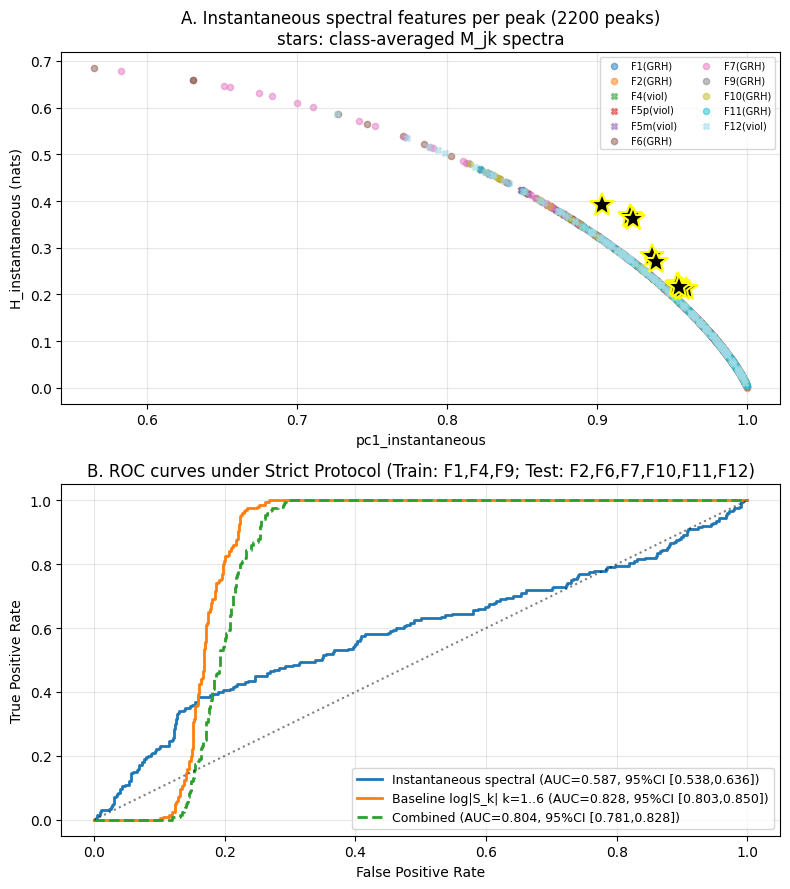

saved figure


In [58]:
# Final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: Scatter of pc1_instantaneous vs H_instantaneous, colored by class, marker by GRH
ax = axes[0]
classes_order = ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12']
colors = plt.cm.tab20(np.linspace(0, 1, 11))
for i, cls in enumerate(classes_order):
 sub = df_aug[df_aug.function==cls]
 grh = sub['GRH'].iloc[0]
 marker = 'o' if grh else 'X'
 ax.scatter(sub['pc1_instantaneous'], sub['H_instantaneous'], 
 c=[colors[i]], marker=marker, alpha=0.5, s=20, label=f'{cls}({"GRH" if grh else "viol"})')
# overlay class-averaged spectral points
for cls, (pc1c, Hc) in class_spectral.items():
 ax.plot(pc1c, Hc, marker='*', color='black', markersize=18, markeredgecolor='yellow', markeredgewidth=1.5)
ax.set_xlabel('pc1_instantaneous')
ax.set_ylabel('H_instantaneous (nats)')
ax.set_title(f'A. Instantaneous spectral features per peak (2200 peaks)\nstars: class-averaged M_jk spectra')
ax.legend(fontsize=7, loc='upper right', ncol=2)
ax.grid(alpha=0.3)

# Panel B: ROC curves for instantaneous vs baseline vs combined
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, scores)
ax.plot(fpr, tpr, label=f'Instantaneous spectral (AUC={auc:.3f}, 95%CI [{ci_lo:.3f},{ci_hi:.3f}])', lw=2)
fpr_b, tpr_b, _ = roc_curve(y_test, scores_b)
ax.plot(fpr_b, tpr_b, label=f'Baseline log|S_k| k=1..6 (AUC={auc_b:.3f}, 95%CI [{ci_lo_b:.3f},{ci_hi_b:.3f}])', lw=2)
fpr_c, tpr_c, _ = roc_curve(y_test, scores_c)
ax.plot(fpr_c, tpr_c, label=f'Combined (AUC={auc_c:.3f}, 95%CI [{ci_lo_c:.3f},{ci_hi_c:.3f}])', lw=2, ls='--')
ax.plot([0,1],[0,1],'k:',alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('B. ROC curves under Strict Protocol (Train: F1,F4,F9; Test: F2,F6,F7,F10,F11,F12)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('instantaneous_spectral_features_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved figure')


In [59]:
from e14c.filesystem import write_file
from pathlib import Path
from textwrap import dedent

memory_path = './.prompts/MEMORY.md'
content = dedent('''
# Project Memory

## Instructions

Edit this file (`./.prompts/MEMORY.md`) to persist context, findings, and notes.
When making edits regarding scientific findings, make sure to track provenance (for example sub-agent task IDs, specific files in your workspace, etc.).

## Context

- Current analysis investigated whether peak-level instantaneous spectral features derived from m_jk(t)=Re(S_j(t) conj(S_k(t))) improve GRH-violator classification under the strict protocol.
- Primary source files used: ` v6 — Binding Context Document.pdf`, `peaks_features_F1_F12_normalized_full.csv`.
- Reconstructed complex S_k(t) for all 2200 CSV peaks across classes F1, F2, F4, F5p, F5m, F6, F7, F9, F10, F11, F12.
- New artifacts created in workspace: `Sk_complex_all_2200peaks.npz`, `instantaneous_spectral_features.csv`, `peaks_features_F1_F12_with_instantaneous_spectral.csv`, `instantaneous_spectral_features_summary.png`, `coeffs_F9_lambda.npy`, `coeffs_F10_lambda.npy`.

## Notes

- Provenance: direct notebook reconstruction in current workspace `/workspace/f74d1baa-053a-481c-b5d1-ecf8e9d1567f/`.
- Verified formulas by exact/near-exact reproduction of CSV `abs_Sk` magnitudes for F1, F4, F9, and F12 (median relative errors ~1e-14 to 1e-15; max relative errors <= 5.4e-10).
- Re-derived coefficient models for F1-F12 classes used here:
 - F1: zeta, a_n=1.
 - F2: primitive order-4 Dirichlet character mod 5, values (1, i, -i, -1, 0) by residue.
 - F4: Davenport-Heilbronn periodic coefficients (1, kappa, -kappa, -1, 0), kappa=0.28408.
 - F5p/F5m: same periodic form with kappa±0.05.
 - F6: Liouville lambda(n)=(-1)^Omega(n).
 - F7: Möbius mu(n).
 - F9: Ramanujan Delta normalized coefficients lambda_n=a_n/n^(11/2), generated with cypari2/PARI.
 - F10: level-11 weight-2 newform normalized coefficients lambda_n=a_n/sqrt(n), generated with cypari2/PARI.
 - F11: Sym^2(Delta) normalized coefficients loaded from local `lambda_n.npy` after identifying `a_n.npy`/`lambda_n.npy` as F11 (not F9) because b_p=tau(p)^2-p^11 matched exactly.
 - F12: complex coefficients from local `a.npy`.
- Key methodological finding: m_jk(t)=Re(S_j conj(S_k)) is the real part of a rank-1 Hermitian outer product and therefore has rank <= 2 (numerically observed as two nonzero eigenvalues and six ~0 eigenvalues). This strongly constrains the information content of peak-level eigenvalue spectra.
- Strict protocol result using only new features [`pc1_instantaneous`, `H_instantaneous`]: held-out AUC=0.587 with 95% bootstrap CI [0.538, 0.636].
- Baseline reproduction using normalized log|S_k|, k=1..6 (excluding S7 leak): AUC=0.828, 95% CI [0.803, 0.850].
- Combined baseline + instantaneous features under same RBF SVM decreased to AUC=0.804, 95% CI [0.781, 0.828].
- Class-level averages of instantaneous features correlate with class-averaged spectral features from M_jk (Pearson r=0.870 for pc1, r=0.896 for entropy across 11 classes), but this correlation does not translate into useful single-peak discrimination.
- Failure mode: RH-respecting F6/F7 peaks occupy nearly the same instantaneous spectral region as DH-type violators F4/F5±, collapsing separability.
''').strip() + '\n'
print(write_file(memory_path, content))
print(Path(memory_path).exists())


File created successfully at: ./.prompts/MEMORY.md
True
